# 06 — Live Demo
**Goal:** Record voice from microphone, extract MFCC features, and predict emotion using the best trained model.

## 1. Install Required Libraries

In [1]:
!pip install sounddevice soundfile --quiet

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import librosa
import joblib
import sounddevice as sd
import soundfile as sf
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

print("Imports done ✅")

Imports done ✅


## 3. Settings

In [5]:
import os
from datetime import datetime

SAMPLE_RATE       = 22050
DURATION          = 3
N_MFCC            = 40

# Create recordings folder
RECORDINGS_FOLDER = 'recordings'
os.makedirs(RECORDINGS_FOLDER, exist_ok=True)

EMOTION_LABELS = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
EMOTION_EMOJIS = {
    'neutral':  '😐',
    'happy':    '😄',
    'sad':      '😢',
    'angry':    '😠',
    'fear':     '😨',
    'disgust':  '🤢',
    'surprise': '😲'
}

print(f"Recording duration: {DURATION} seconds")
print(f"Sample rate:        {SAMPLE_RATE} Hz")
print(f"Recordings folder:  {RECORDINGS_FOLDER}/")
print("Settings ready ✅")

Recording duration: 3 seconds
Sample rate:        22050 Hz
Recordings folder:  recordings/
Settings ready ✅


## 4. Load Best Model and Scaler

In [6]:
# Read best model name
with open('best_model_name.txt', 'r') as f:
    best_model_name = f.read().strip()

# Load scaler
scaler = joblib.load('scaler.pkl')

# Load model
if best_model_name == 'CNN':
    from tensorflow.keras.models import load_model
    model = load_model('best_model.h5')
else:
    model = joblib.load('best_model.pkl')

print(f"Loaded model: {best_model_name} ✅")
print(f"Loaded scaler ✅")

Loaded model: MLP ✅
Loaded scaler ✅


## 5. Feature Extraction Function

In [7]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION, mono=True)

    # Pad if shorter than duration
    target_length = SAMPLE_RATE * DURATION
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_mean = np.mean(mfcc, axis=1)

    return mfcc_mean

print("Feature extraction function ready ✅")

Feature extraction function ready ✅


## 6. Record Voice

In [80]:
# Generate timestamped filename
timestamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
RECORD_FILE = os.path.join(RECORDINGS_FOLDER, f'recording_{timestamp}.wav')

print(f"🎙️  Recording for {DURATION} seconds...")
print("     Speak now!")

# Record audio
recording = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype='float32'
)
sd.wait()  # wait until recording is done

# Save to file
sf.write(RECORD_FILE, recording, SAMPLE_RATE)
print(f"✅ Recording complete!")
print(f"   Saved as: {RECORD_FILE}")

🎙️  Recording for 3 seconds...
     Speak now!
✅ Recording complete!
   Saved as: recordings\recording_20260624_022305.wav


## 7. Plot Recorded Waveform

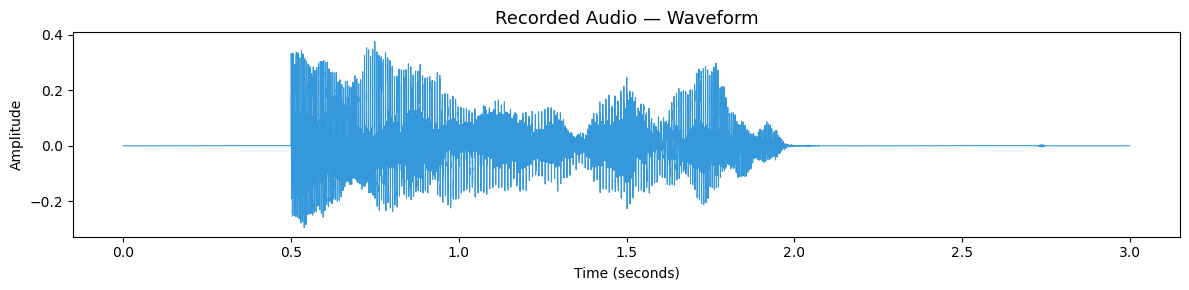

In [81]:
y, sr = librosa.load(RECORD_FILE, sr=SAMPLE_RATE)

plt.figure(figsize=(12, 3))
plt.plot(np.linspace(0, DURATION, len(y)), y, color='#3498db', linewidth=0.8)
plt.title('Recorded Audio — Waveform', fontsize=13)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## 8. Predict Emotion

In [82]:
# Extract features
features = extract_features(RECORD_FILE)
features_scaled = scaler.transform(features.reshape(1, -1))

# Predict
if best_model_name == 'CNN':
    features_cnn = features_scaled.reshape(1, features_scaled.shape[1], 1)
    probabilities = model.predict(features_cnn)[0]
else:
    probabilities = model.predict_proba(features_scaled)[0]

# Get predicted emotion
predicted_idx      = np.argmax(probabilities)
predicted_emotion  = EMOTION_LABELS[predicted_idx]
predicted_emoji    = EMOTION_EMOJIS[predicted_emotion]
confidence         = probabilities[predicted_idx] * 100

print(f"\n{'='*40}")
print(f"  {predicted_emoji}  Predicted Emotion: {predicted_emotion.upper()}")
print(f"      Confidence: {confidence:.2f}%")
print(f"{'='*40}")


  😄  Predicted Emotion: HAPPY
      Confidence: 84.11%


## 9. Show All Emotion Probabilities


Emotion Probabilities:
  😐 neutral                                   0.0%
  😄 happy                                     0.0%
  😢 sad                                       0.0%
  😠 angry                                     0.0%
  😨 fear                                      0.0%
  🤢 disgust                                   0.0%
  😲 surprise   █████████████████████████████  100.0% ← predicted


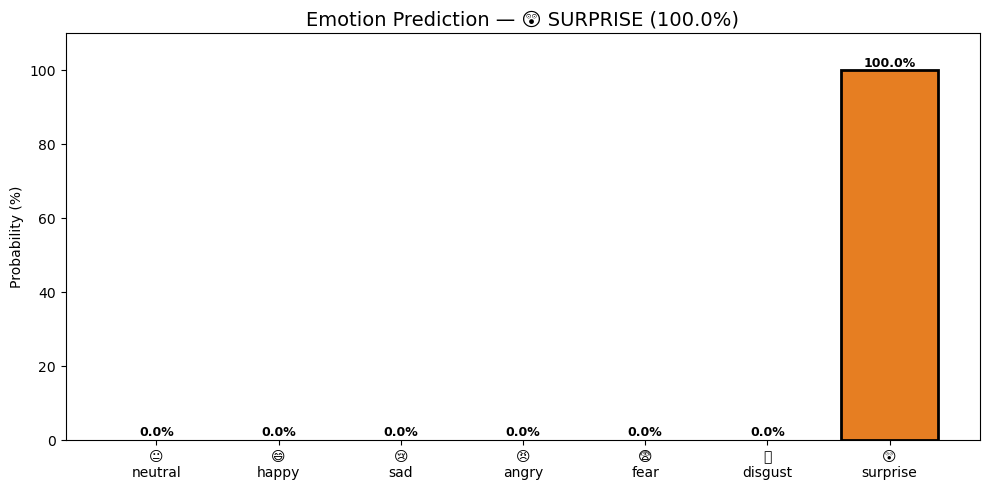

Saved: demo_prediction.png


In [14]:
# Print probability bars
print("\nEmotion Probabilities:")
for emotion, prob in zip(EMOTION_LABELS, probabilities):
    bar   = '█' * int(prob * 30)
    emoji = EMOTION_EMOJIS[emotion]
    marker = ' ← predicted' if emotion == predicted_emotion else ''
    print(f"  {emoji} {emotion:<10} {bar:<30} {prob*100:.1f}%{marker}")

# Plot probability bar chart
EMOTION_COLORS = {
    'neutral': '#7f8c8d', 'happy': '#f1c40f', 'sad': '#3498db',
    'angry': '#e74c3c', 'fear': '#9b59b6', 'disgust': '#27ae60', 'surprise': '#e67e22'
}
colors = [EMOTION_COLORS[e] for e in EMOTION_LABELS]

plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f"{EMOTION_EMOJIS[e]}\n{e}" for e in EMOTION_LABELS],
    probabilities * 100,
    color=colors,
    edgecolor=['black' if e == predicted_emotion else 'none' for e in EMOTION_LABELS],
    linewidth=2
)
plt.title(f'Emotion Prediction — {predicted_emoji} {predicted_emotion.upper()} ({confidence:.1f}%)', fontsize=14)
plt.ylabel('Probability (%)')
plt.ylim([0, 110])
for bar, prob in zip(bars, probabilities):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{prob*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: demo_prediction.png')

## 10. Try Again
Want to record again? Just re-run **Cell 6, 7, 8, and 9** — no need to reload the model.

---
**Done!** 🎉 All 6 notebooks complete. Your Speech Emotion Recognition project is ready!

In [46]:
# Debug prediction pipeline
features = extract_features(RECORD_FILE)
print(f"Raw features shape: {features.shape}")
print(f"Raw features (first 5): {features[:5].round(3)}")

features_scaled = scaler.transform(features.reshape(1, -1))
print(f"\nScaled features (first 5): {features_scaled[0][:5].round(3)}")

probabilities = model.predict_proba(features_scaled)[0]
print(f"\nAll probabilities:")
for emotion, prob in zip(EMOTION_LABELS, probabilities):
    bar = '█' * int(prob * 30)
    print(f"  {emotion:<10} {bar:<30} {prob*100:.1f}%")

print(f"\nPredicted: {EMOTION_LABELS[np.argmax(probabilities)].upper()}")

Raw features shape: (40,)
Raw features (first 5): [-521.795   31.772  -34.859    4.779  -20.774]

Scaled features (first 5): [-0.055 -0.727 -2.607 -0.247 -2.258]

All probabilities:
  neutral                                   0.0%
  happy                                     0.3%
  sad                                       0.0%
  angry      █████████                      30.9%
  fear                                      0.0%
  disgust                                   0.7%
  surprise   ████████████████████           68.2%

Predicted: SURPRISE


In [64]:
# Test with an actual RAVDESS file
test_file = "data\TESS\OAF_bar_happy.wav"  # happy file
features = extract_features(test_file)
features_scaled = scaler.transform(features.reshape(1, -1))
probabilities = model.predict_proba(features_scaled)[0]
predicted = EMOTION_LABELS[np.argmax(probabilities)]
print(f"File: {test_file}")
print(f"Predicted: {predicted.upper()} ({max(probabilities)*100:.1f}%)")

File: data\TESS\OAF_bar_happy.wav
Predicted: HAPPY (100.0%)


In [ ]:
OAF_back_fear.wav
OAF_bar_happy.wav